In [1]:
import os,pickle,re

import numpy as np
import pandas as pd
from sklearn.metrics import make_scorer,mean_absolute_error,mean_squared_error
import shap

from project_package.visualization import Model_Visualizer
from project_package import evaluation,modeling

In [ ]:
# choose to test either full version or lite version
use_lite_version = True
if use_lite_version:
    base_directory = 'supervised_lite'
else:
    base_directory = 'supervised'

# setting
recalculate_evaluation = False

#### Problem 2: Regression (booking fare prediction)

In [3]:
files = os.listdir(base_directory)

file = [item for item in files if 'Booking Value_fill_scaled.pkl' in item][0]

model_path = os.path.join(base_directory, file)

with open(model_path, "rb") as f:
    model = pickle.load(f)
model

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x000002509D8958B0>),
                                                 ('cat',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x000002509D9E5B80>)])),
                ('reg', DecisionTreeRegressor(max_depth=3, random_state=42))])

Load the train and test data

In [4]:
split_df = pd.read_csv(os.path.join(base_directory, 'split_assignments_regression_Booking_Value_fill_scaled.csv'))

if use_lite_version:
    model_data =pd.read_csv('ncr_ride_bookings_with_weather_filled_scaled_short__Booking_Value_fill_scaled__top20_s30.csv')
else:
    model_data =pd.read_csv('ncr_ride_bookings_with_weather_filled_scaled_short.csv')

In [6]:
feature_cols = [re.sub(r'^num__', '', name) for name in model[0].get_feature_names_out()]
feature_cols = [re.sub(r'cat__', '', name) for name in feature_cols]
get_cols = ['Booking Value_fill_scaled'] + feature_cols

# train data
train_split = split_df.loc[split_df.split=='train'][['Booking ID','Customer ID']]
train_data = model_data.merge(train_split,on=['Booking ID','Customer ID'])
y_train = train_data['Booking Value_fill_scaled']
train_data = modeling.drop_unnecessary_cols(train_data)
train_data['Booking Value_fill_scaled'] = y_train
# validation data
test_split = split_df.loc[split_df.split=='valid'][['Booking ID','Customer ID']]
test_data = model_data.merge(test_split,on=['Booking ID','Customer ID'])
y_test = test_data['Booking Value_fill_scaled']
test_data = modeling.drop_unnecessary_cols(test_data)
test_data['Booking Value_fill_scaled'] = y_test

train_data = train_data[get_cols]
test_data = test_data[get_cols]

In [7]:
prediction_df = pd.read_csv(f'{base_directory}/reg_best_Booking_Value_fill_scaled_tree_preds.csv')

# check model metric score
print('---------on training dataset--------------')
print('MAE from model:',mean_absolute_error(y_train,model.predict(train_data)))
print()
print('MSE from model:',mean_squared_error(y_train,model.predict(train_data)))

print()
print('---------on test dataset--------------')
print('MAE from model:',mean_absolute_error(y_test,model.predict(test_data)))
print('MAE from file:',mean_absolute_error(prediction_df.y_true,prediction_df.y_pred))
print()
print('MSE from model:',mean_squared_error(y_test,model.predict(test_data)))
print('MSE from file:',mean_squared_error(prediction_df.y_true,prediction_df.y_pred))

---------on training dataset--------------
MAE from model: 0.9679072548273839

MSE from model: 2.5804548765172663

---------on test dataset--------------
MAE from model: 0.946475570446578
MAE from file: 0.9464755704465778

MSE from model: 2.4837996836066027
MSE from file: 2.4837996836066027


In [8]:
# create visualization object

reg_vis_obj = Model_Visualizer(
    train_data,
    test_data,
    y_train,
    y_test,
    feature_names = feature_cols,
    target_name='Booking Value_fill_scaled'
    )

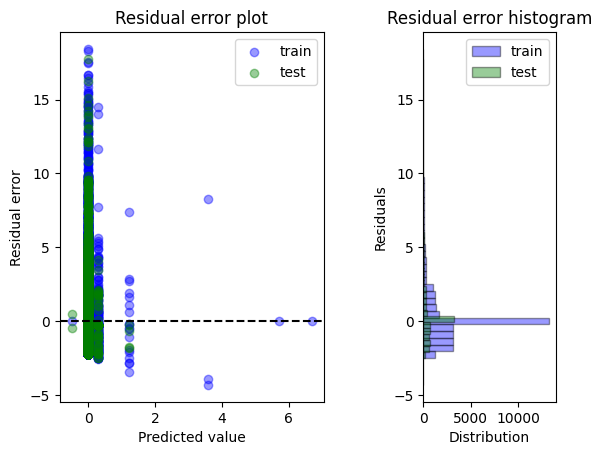

In [9]:
#residue plot 
reg_vis_obj.residual_plot(model,bins=50,alpha=0.4)

Feature Importance and Ablation Analysis

<Axes: title={'center': 'Feature Importance plot'}, xlabel='Importance', ylabel='Features'>

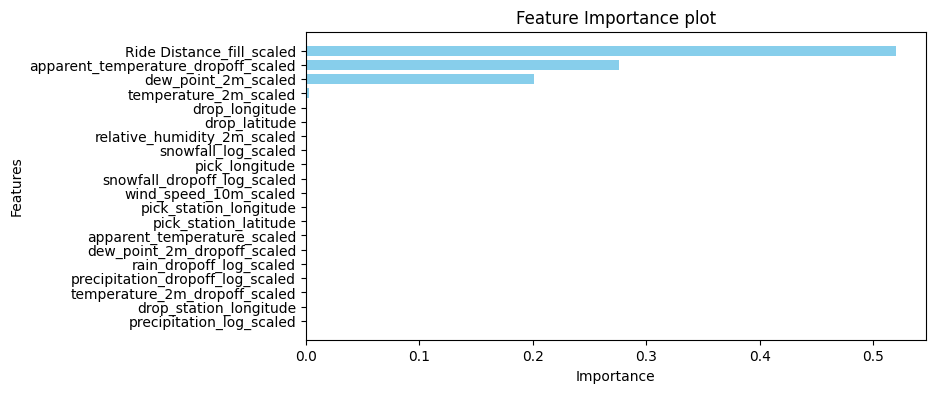

In [10]:
reg_vis_obj.feature_importance_plot(model.named_steps['reg'].feature_importances_,normalize=False,top_n=20)

In [11]:
try:
    os.makedirs(f'{base_directory}/evaluation', exist_ok=True)

    if not recalculate_evaluation:
        with open(base_directory + "/evaluation/booking_fare_permutation_train_result.pkl", "rb") as f:
            train_permute = pickle.load(f)
        with open(base_directory + "/evaluation/booking_fare_permutation_test_result.pkl", "rb") as f:
            test_permute = pickle.load(f)
    else:
        raise Exception('Recalculating permutation test')
except:
    train_permute,test_permute = evaluation.permutation_test(
        model,train_data,test_data,
        target_col = 'Booking Value_fill_scaled',scorer='neg_mean_absolute_error',random_state=0,n_jobs=-1
    )

    with open(base_directory + "/evaluation/booking_fare_permutation_train_result.pkl", "wb") as f:
        pickle.dump(train_permute, f)

    with open(base_directory + "/evaluation/booking_fare_permutation_test_result.pkl", "wb") as f:
        pickle.dump(test_permute, f)

<Axes: title={'center': 'Permutation importance on train data'}, xlabel='Decrease in metric score'>

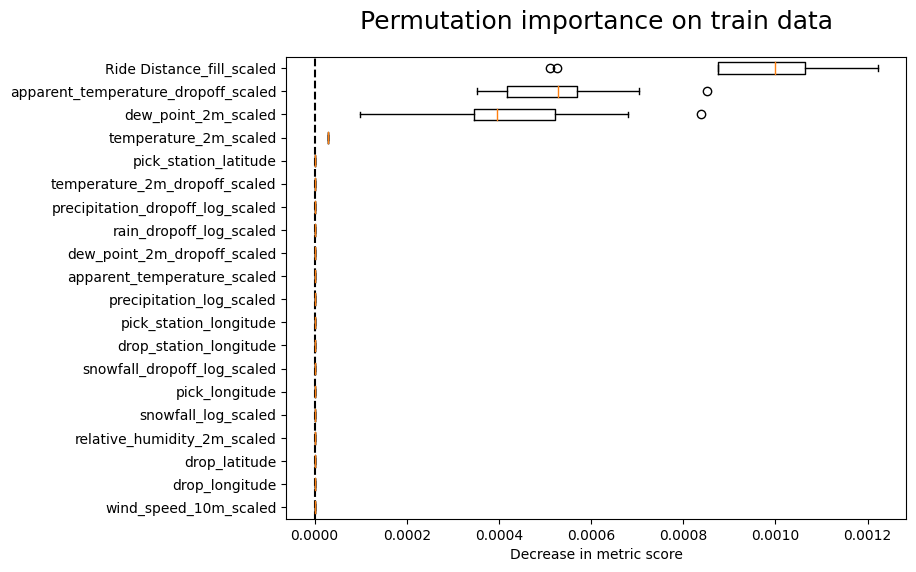

In [12]:
reg_vis_obj.permutation_importance_plot(train_permute,figsize=(8,6),title='Permutation importance on train data')

<Axes: title={'center': 'Permutation importance on test data'}, xlabel='Decrease in metric score'>

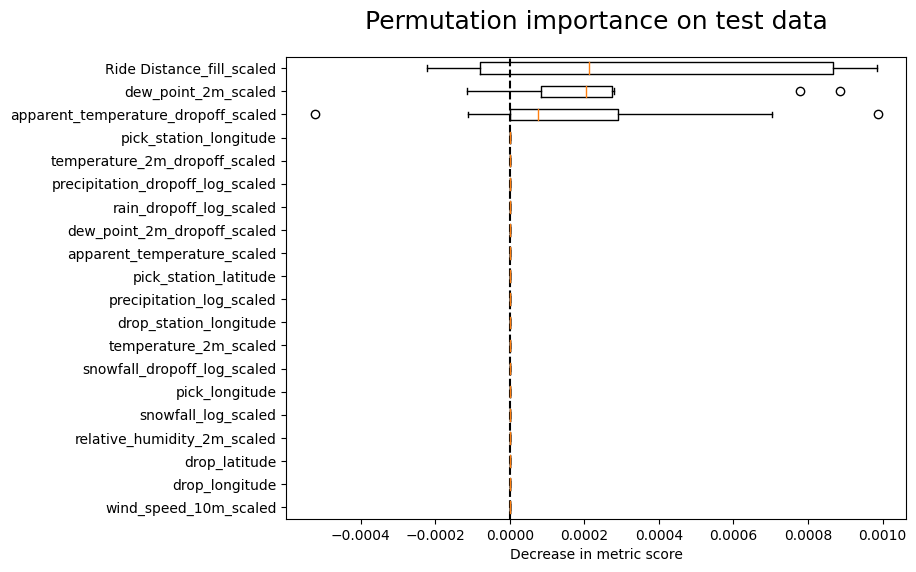

In [13]:
reg_vis_obj.permutation_importance_plot(test_permute,figsize=(8,6),title='Permutation importance on test data')

In [14]:
try:
    os.makedirs(f'{base_directory}/evaluation', exist_ok=True)
    if not recalculate_evaluation:
        score_array = np.load(base_directory + '/evaluation/booking_fare_ablation_test.npy')
        eval_df = pd.read_csv(base_directory + '/evaluation/booking_fare_ablation_test.csv')
    else:
        raise Exception('Recalculating ablation test')
except:
    remove_features = ['dew_point_2m_scaled',
                   'apparent_temperature_dropoff_scaled',
                   'Ride Distance_fill_scaled',
                   ['dew_point_2m_scaled','apparent_temperature_dropoff_scaled','Ride Distance_fill_scaled']
                    ]

    score_array,eval_df = evaluation.ablation_test(
        model,
        train_data = train_data,
        test_data = test_data,
        target_col = 'Booking Value_fill_scaled',
        scorer=make_scorer(mean_absolute_error),
        stratify=False,
        remove_features = remove_features,
        n_jobs=-1
    )

    np.save(base_directory + '/evaluation/booking_fare_ablation_test.npy',score_array)
    eval_df.to_csv(base_directory + '/evaluation/booking_fare_ablation_test.csv',index=False)

eval_df.head()

,remove_features,score_mean,score_std,score_test
0,none,0.972678,0.017463,0.967907
1,dew_point_2m_scaled,0.970830,0.018490,0.948027
2,apparent_temperature_dropoff_scaled,0.972488,0.017445,0.947998
3,Ride Distance_fill_scaled,0.974737,0.018468,0.954245
4,"[dew_point_2m_scaled, apparent_temperature_dro...",0.972060,0.019488,0.954238


<Axes: title={'center': 'Ablation test'}, xlabel='mean absolute error'>

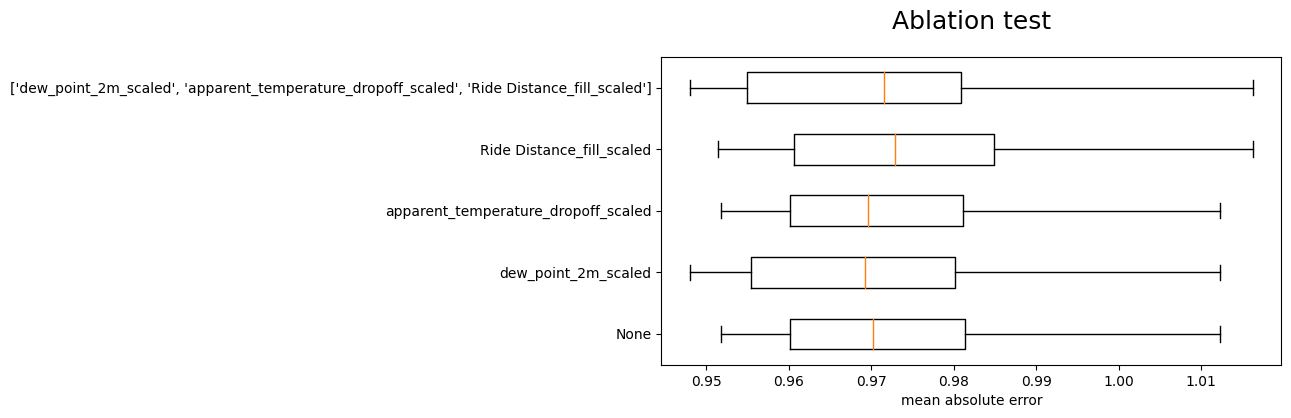

In [15]:
# Ablation test plot
reg_vis_obj.box_plot(score_array.T,labels=['None'] + remove_features,title='Ablation test',xlabel='mean absolute error')

Sensivity analysis

In [ ]:
try:
    os.makedirs(f'{base_directory}/evaluation', exist_ok=True)
    if not recalculate_evaluation:
        eval_df = pd.read_csv(base_directory + '/evaluation/booking_fare_sensivity_test.csv')
    else:
        raise Exception('Recalculating sensivity test')
except:
    grids = {
        'reg__min_samples_leaf':np.linspace(1,7,7).astype(int),
        'reg__max_depth':np.linspace(1,7,7).astype(int)
    }
    eval_df = evaluation.supervised_sensivity_test(
        model,train_data,
        target_col='Booking Value_fill_scaled',
        param_grid=grids,
        scoring = 'neg_mean_absolute_error',
        verbose=0,
        n_jobs=-1
    )
    eval_df.to_csv(base_directory + '/evaluation/booking_fare_sensivity_test.csv',index=False)
eval_df.head()

In [ ]:
plot_1_cond = eval_df.reg__min_samples_leaf.unique()[1]
plot_2_cond = eval_df.reg__max_depth.unique()[2]

reg_vis_obj.sensivity_plot(eval_df,
               'neg_mean_absolute_error',
               param1 = ('reg__max_depth','reg__min_samples_leaf',plot_1_cond),
               param2 = ('reg__min_samples_leaf','reg__max_depth',plot_2_cond),
               subplot_titles = [
                   f'Sensivity vs. max_depth (with min_samples_leaf={plot_1_cond})',
                   f'Sensivity vs. min_samples_leaf (with max_depth={plot_2_cond})',
                   None
               ]
               )

Learning curve

In [ ]:
try:
    os.makedirs(f'{base_directory}/evaluation', exist_ok=True)
    if not recalculate_evaluation:
        result_df = pd.read_csv(base_directory + '/evaluation/booking_fare_learning_curve.csv')
    else:
        raise Exception('Recalculating learning curve')
except:
    _,_,result_df = evaluation.learning_curve_test(
    model,train_data,
    target_col='Booking Value_fill_scaled',
    sample_range=np.linspace(1000,35000,35).astype(int),
    scorer = make_scorer(mean_absolute_error),
    stratify=False,
    n_jobs=-1
    )

    result_df.to_csv(base_directory + '/evaluation/booking_fare_learning_curve.csv',index=False)

result_df.head(5)

,n_sample,score_mean,score_std
0,1000,1.047487,0.095748
1,2000,1.019149,0.079360
2,3000,0.991772,0.069737
3,4000,0.971048,0.062551
4,5000,0.950343,0.057324


<Axes: title={'center': 'Learning curve analysis'}, xlabel='No. of training records', ylabel='mean absolute error'>

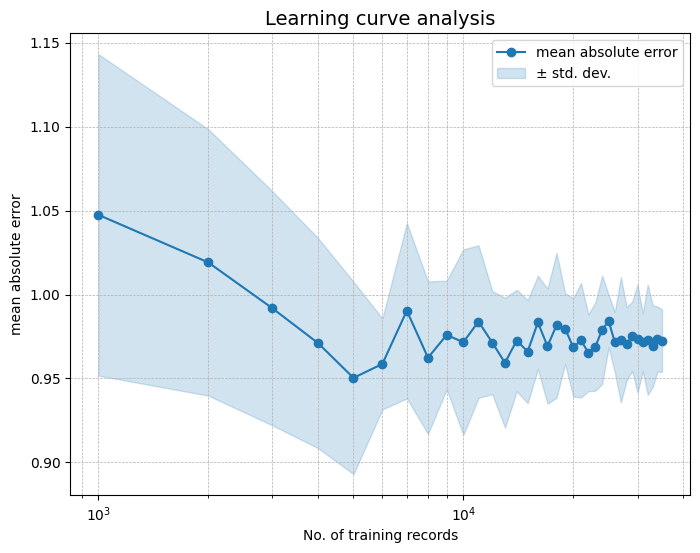

In [ ]:
# Learning curve plot

reg_vis_obj.learning_curve_plot(
    np.linspace(1000,35000,35).astype(int),
    result_df.score_mean,
    result_df.score_std,
    log_sample=True,
    metric_label = 'mean absolute error'
    )

Failure analysis (regression)

In [ ]:
# get worst examples on residual error
ex_df,ex_info_df = evaluation.get_worst_examples(
    model,test_data,
    get_n=10,
    target_col='Booking Value_fill_scaled',
    problem_type='regression',
    get_random_err=False,
    random_state=0
)

test_shap_values,_ = evaluation.shap_analysis(
    model,
    shap.TreeExplainer,
    train_df = shap.sample(train_data,nsamples=1000), # recommended number in documentation
    test_df = shap.sample(test_data),
    target_col = 'Booking Value_fill_scaled'
)

ex_shap_values,_ = evaluation.shap_analysis(
    model,
    shap.TreeExplainer,
    train_df = shap.sample(train_data,nsamples=1000),  # recommended number in documentation
    test_df = ex_df,
    target_col = 'Booking Value_fill_scaled'
)
ex_info_df

,true_value,predicted_value,residual,absolute_residual
1983,17.754630,-0.004603,17.759233,17.759233
1967,16.279380,-0.004603,16.283983,16.283983
292,15.081361,-0.004603,15.085964,15.085964
3130,14.640767,-0.004603,14.645370,14.645370
5459,14.249678,-0.004603,14.254281,14.254281
5353,13.967500,-0.004603,13.972103,13.972103
5424,13.809084,-0.004603,13.813687,13.813687
5016,13.343738,-0.004603,13.348341,13.348341
2805,13.041757,-0.004603,13.046360,13.046360
2167,12.967500,-0.004603,12.972103,12.972103


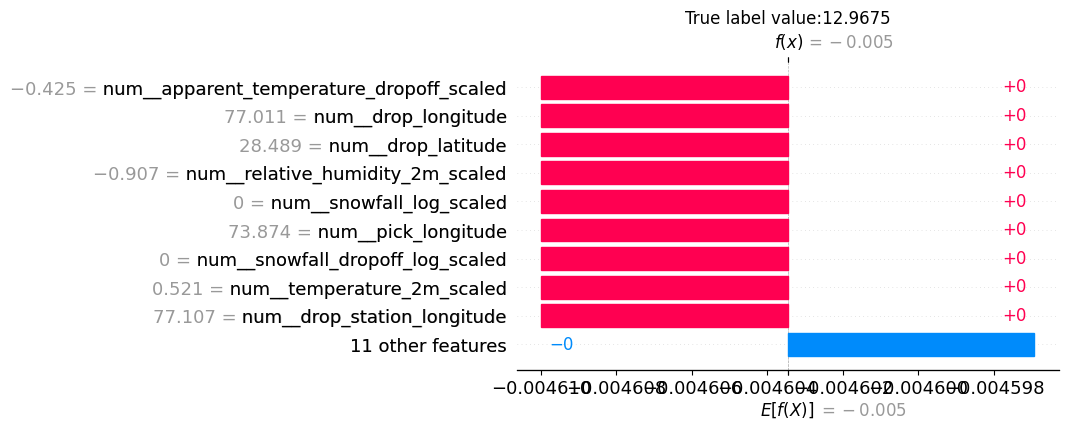

In [ ]:
# water fall plot

true_val = ex_df['Booking Value_fill_scaled'].iloc[-1]
reg_vis_obj.waterfall_plot(
    ex_shap_values[-1],
    title = f'True label value:{true_val}',
    figsize=(7,4)
    )

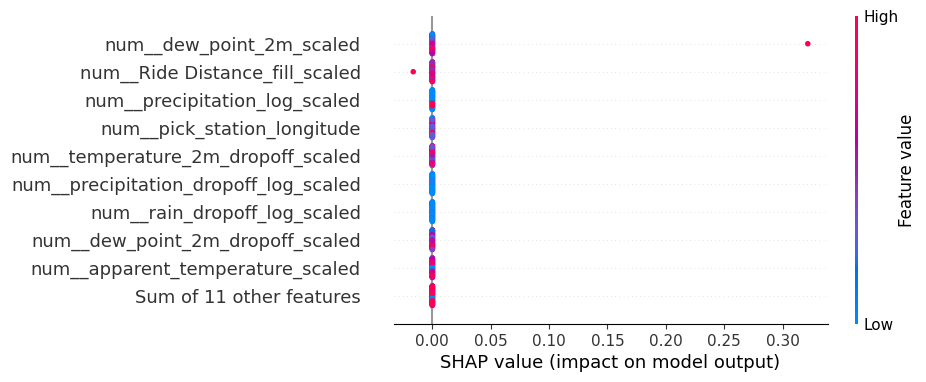

In [ ]:
# beeswarm plot

reg_vis_obj.beeswarm_plot(
    test_shap_values,
    figsize=(7,4)
    )